# Advertising Sales Prediction (Sklearn Version)

In this notebook, we use the `Advertising.csv` dataset to predict sales based on advertising budgets for TV, Radio, and Newspaper.
We'll use **Linear Regression** from scikit-learn and evaluate the model's performance.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


## 1️⃣ Load and Explore the Dataset
We'll start by loading the `Advertising.csv` file and inspecting its structure.


In [7]:
# Load the dataset
# data = pd.read_csv("../data/Advertising.csv")
data = pd.read_csv("data/Advertising.csv")


# Remove any unnamed index column if it exists
if "Unnamed: 0" in data.columns:
    data = data.drop(columns=["Unnamed: 0"])

# Show first 5 rows
data.head()


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## 2️⃣ Data Summary and Visualization
Let's explore the dataset — shape, summary stats, and relationships between features and Sales.


In [8]:
print("Shape:", data.shape)
print("\nColumns:", data.columns.tolist())
print("\nMissing values:\n", data.isnull().sum())

# Quick statistical overview
data.describe()


Shape: (200, 4)

Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

Missing values:
 TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


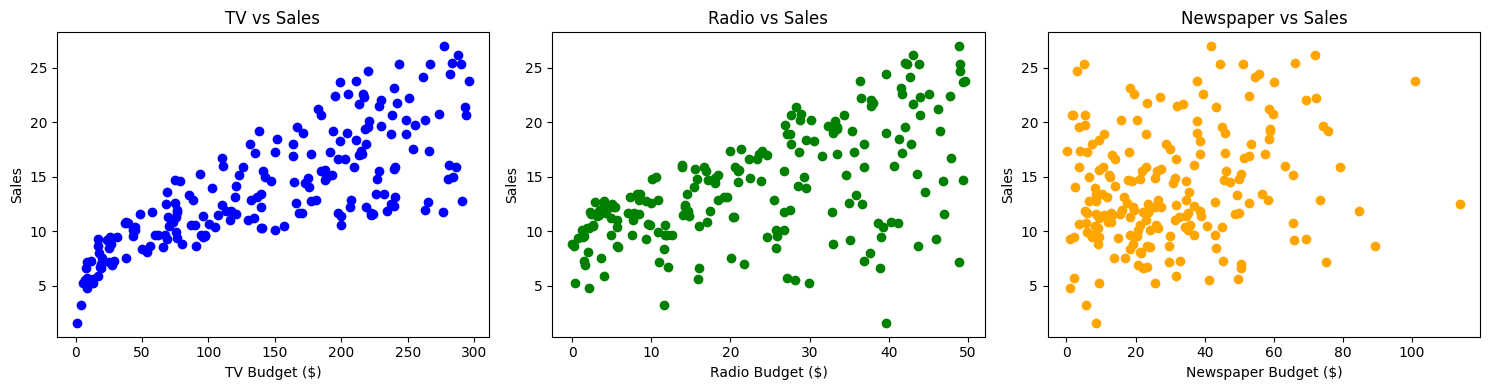

In [9]:
# Scatter plots for each feature vs Sales
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].scatter(data['TV'], data['Sales'], color='blue')
axes[0].set_title("TV vs Sales")
axes[0].set_xlabel("TV Budget ($)")
axes[0].set_ylabel("Sales")

axes[1].scatter(data['Radio'], data['Sales'], color='green')
axes[1].set_title("Radio vs Sales")
axes[1].set_xlabel("Radio Budget ($)")
axes[1].set_ylabel("Sales")

axes[2].scatter(data['Newspaper'], data['Sales'], color='orange')
axes[2].set_title("Newspaper vs Sales")
axes[2].set_xlabel("Newspaper Budget ($)")
axes[2].set_ylabel("Sales")

plt.tight_layout()
plt.show()


## 3️⃣ Train/Test Split
We'll split the dataset into training and testing sets — 80% for training and 20% for testing.


In [10]:
X = data[['TV', 'Radio', 'Newspaper']]
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (160, 3)
Testing set size: (40, 3)


## 4️⃣ Train Linear Regression Model
We'll use the LinearRegression class from sklearn to fit our model.


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Intercept:", model.intercept_)
print("Coefficients:", model.coef_)


Intercept: 2.9790673381226327
Coefficients: [0.04472952 0.18919505 0.00276111]


## 5️⃣ Evaluate Model
Let's test the model on the test set and calculate:
- Mean Squared Error (MSE)
- Root Mean Squared Error (RMSE)
- R² (coefficient of determination)


In [12]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"R²: {r2:.3f}")


MSE: 3.174
RMSE: 1.782
R²: 0.899


## 6️⃣ Visualize Predictions vs Actual Sales


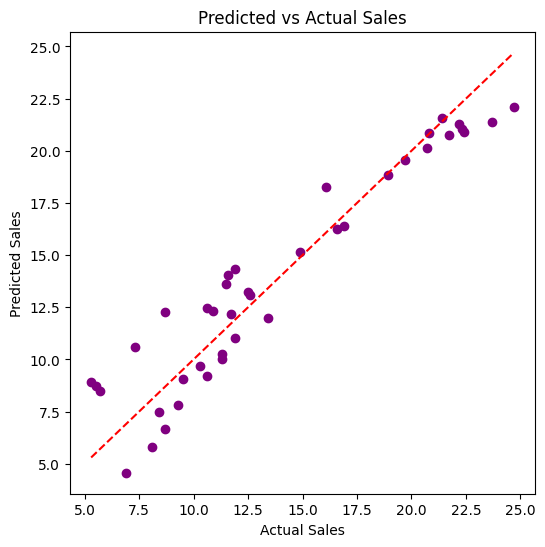

In [13]:
plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, color='purple')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Predicted vs Actual Sales")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()


In [14]:
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
coef_df


,Feature,Coefficient
0,TV,0.044730
1,Radio,0.189195
2,Newspaper,0.002761


THE END


In [15]:
# Feature (independent variable)
X = data[["TV"]]  # Note the double brackets -> keeps it as a 2D array

# Target (dependent variable)
y = data["Sales"]


In [16]:
model = LinearRegression()
model.fit(X, y)


LinearRegression()

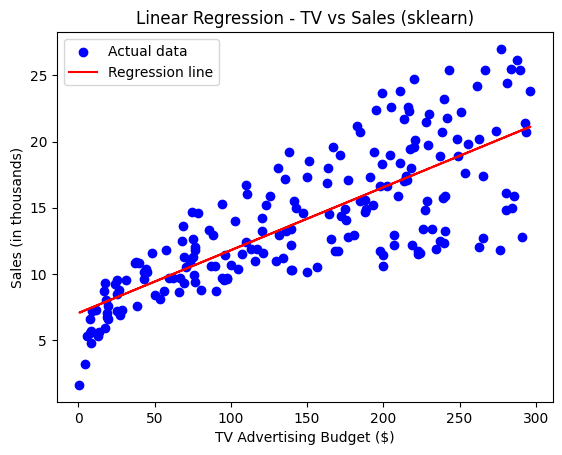

In [17]:
# Predict sales for each TV value
y_pred = model.predict(X)

# Plot the data points
plt.scatter(X, y, color='blue', label="Actual data")

# Plot the regression line
plt.plot(X, y_pred, color='red', label="Regression line")

plt.xlabel("TV Advertising Budget ($)")
plt.ylabel("Sales (in thousands)")
plt.title("Linear Regression - TV vs Sales (sklearn)")
plt.legend()
plt.show()


In [18]:
print("Slope (coefficient):", model.coef_[0])
print("Intercept:", model.intercept_)
print("R² score:", model.score(X, y))


Slope (coefficient): 0.04753664043301979
Intercept: 7.0325935491276885
R² score: 0.611875050850071


Calculate manually

In [19]:
# Convert to numpy arrays for manual math
X = data["TV"].values
y = data["Sales"].values

# Means
X_mean = np.mean(X)
y_mean = np.mean(y)

# Numerator and denominator for slope (a)
numerator = np.sum((X - X_mean) * (y - y_mean))
denominator = np.sum((X - X_mean)**2)
a = numerator / denominator

# Intercept (b)
b = y_mean - a * X_mean

print("Manual slope (a):", a)
print("Manual intercept (b):", b)


Manual slope (a): 0.047536640433019736
Manual intercept (b): 7.0325935491276965


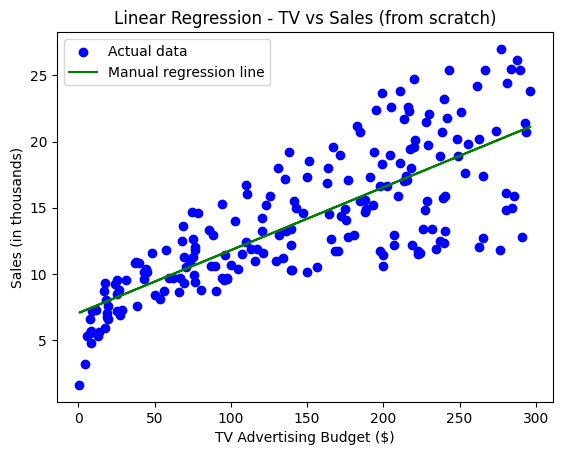

In [20]:
# Manual predictions
y_pred_manual = a * X + b

# Plot both lines together
plt.scatter(X, y, color='blue', label="Actual data")
plt.plot(X, y_pred_manual, color='green', label="Manual regression line")

plt.xlabel("TV Advertising Budget ($)")
plt.ylabel("Sales (in thousands)")
plt.title("Linear Regression - TV vs Sales (from scratch)")
plt.legend()
plt.show()


Exercise 2 – Advertising problem (multiple regression)

In [21]:
# Independent variables (features)
X = data[["TV", "Radio", "Newspaper"]]

# Dependent variable (target)
y = data["Sales"]


In [22]:
model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [23]:
print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)
print("R² score:", model.score(X, y))


Coefficients: [ 0.04576465  0.18853002 -0.00103749]
Intercept: 2.9388893694594014
R² score: 0.8972106381789522


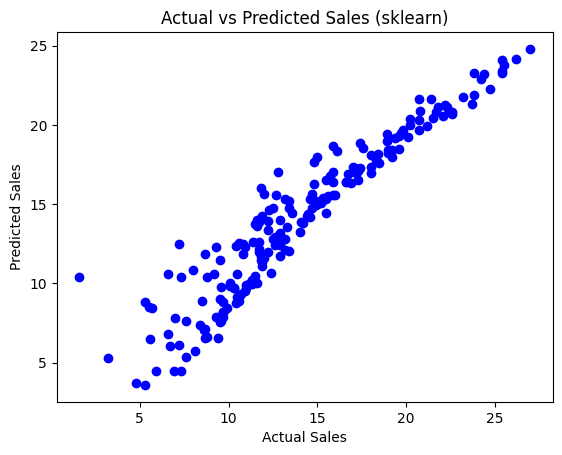

In [24]:
y_pred = model.predict(X)

plt.scatter(y, y_pred, color='blue')
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (sklearn)")
plt.show()


regression manually

In [25]:


# 1. Prepare X and y as NumPy arrays
X = data[["TV", "Radio", "Newspaper"]].values
y = data["Sales"].values

# 2. Add a column of 1s to X for the intercept term
X_b = np.c_[np.ones((X.shape[0], 1)), X]  # shape (200, 4)

# 3. Apply the Normal Equation
beta = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

# 4. Extract parameters
intercept = beta[0]
coefficients = beta[1:]

print("Intercept (manual):", intercept)
print("Coefficients (manual):", coefficients)


Intercept (manual): 2.9388893694594294
Coefficients (manual): [ 0.04576465  0.18853002 -0.00103749]


In [26]:
# Predictions
y_pred_manual = X_b.dot(beta)

# R² = 1 - (SS_res / SS_tot)
ss_res = np.sum((y - y_pred_manual) ** 2)
ss_tot = np.sum((y - np.mean(y)) ** 2)
r2_manual = 1 - (ss_res / ss_tot)

print("R² (manual):", r2_manual)


R² (manual): 0.8972106381789522


Exercise 3 “How much does a student’s score depend on the number of study hours?”

In [27]:


data2 = pd.DataFrame({
    "Hours": [1.5, 3.0, 4.5, 5.5, 6.5, 8.0],
    "Score": [20, 50, 75, 85, 90, 96]
})
data2


,Hours,Score
0,1.5,20
1,3.0,50
2,4.5,75
3,5.5,85
4,6.5,90
5,8.0,96


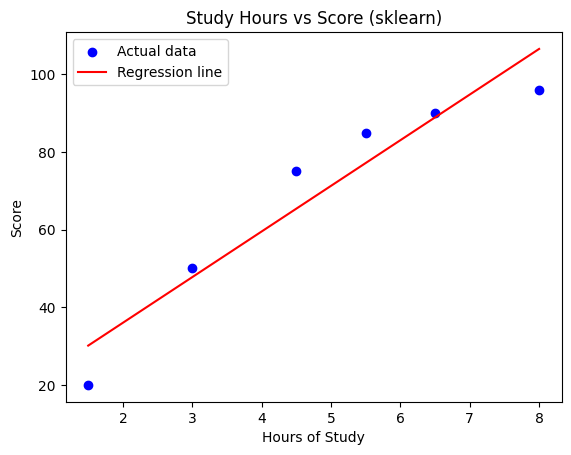

Coefficient (slope): 11.760479041916165
Intercept: 12.491017964071865
R² score: 0.9115067418438577


In [28]:


# Variables
X = data2[["Hours"]]
y = data2["Score"]

# Model
model2 = LinearRegression()
model2.fit(X, y)

# Predict
y_pred = model2.predict(X)

# Plot
plt.scatter(X, y, color='blue', label="Actual data")
plt.plot(X, y_pred, color='red', label="Regression line")
plt.xlabel("Hours of Study")
plt.ylabel("Score")
plt.title("Study Hours vs Score (sklearn)")
plt.legend()
plt.show()

# Results
print("Coefficient (slope):", model2.coef_[0])
print("Intercept:", model2.intercept_)
print("R² score:", model2.score(X, y))


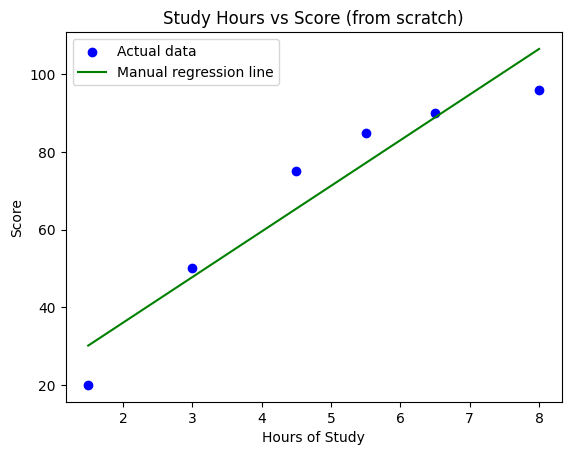

Manual slope (a): 11.760479041916168
Manual intercept (b): 12.491017964071851
Manual R²: 0.9115067418438577


In [29]:


X = data2["Hours"].values
y = data2["Score"].values

# Means
X_mean = np.mean(X)
y_mean = np.mean(y)

# Slope and intercept
a = np.sum((X - X_mean) * (y - y_mean)) / np.sum((X - X_mean)**2)
b = y_mean - a * X_mean

# Predictions
y_pred_manual = a * X + b

# R² manually
ss_res = np.sum((y - y_pred_manual)**2)
ss_tot = np.sum((y - y_mean)**2)
r2_manual = 1 - (ss_res / ss_tot)

# Plot
plt.scatter(X, y, color='blue', label="Actual data")
plt.plot(X, y_pred_manual, color='green', label="Manual regression line")
plt.xlabel("Hours of Study")
plt.ylabel("Score")
plt.title("Study Hours vs Score (from scratch)")
plt.legend()
plt.show()

print("Manual slope (a):", a)
print("Manual intercept (b):", b)
print("Manual R²:", r2_manual)
